Epoch 1, Train Loss: 0.0019, Val Loss: 0.0011
Epoch 2, Train Loss: 0.0011, Val Loss: 0.0010
Epoch 3, Train Loss: 0.0011, Val Loss: 0.0010
Epoch 4, Train Loss: 0.0010, Val Loss: 0.0011
Epoch 5, Train Loss: 0.0010, Val Loss: 0.0012
Epoch 6, Train Loss: 0.0010, Val Loss: 0.0012
Epoch 7, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 8, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 9, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 10, Train Loss: 0.0010, Val Loss: 0.0011
Epoch 11, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 12, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 13, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 14, Train Loss: 0.0010, Val Loss: 0.0011
Epoch 15, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 16, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 17, Train Loss: 0.0010, Val Loss: 0.0010
Early stopping triggered.

Final Model Evaluation:
MAE: 31.4778
MSE: 4138.5293
RMSE: 64.3314
R² Score: 0.7562
MAPE: 19.91%
Accuracy: 80.09%


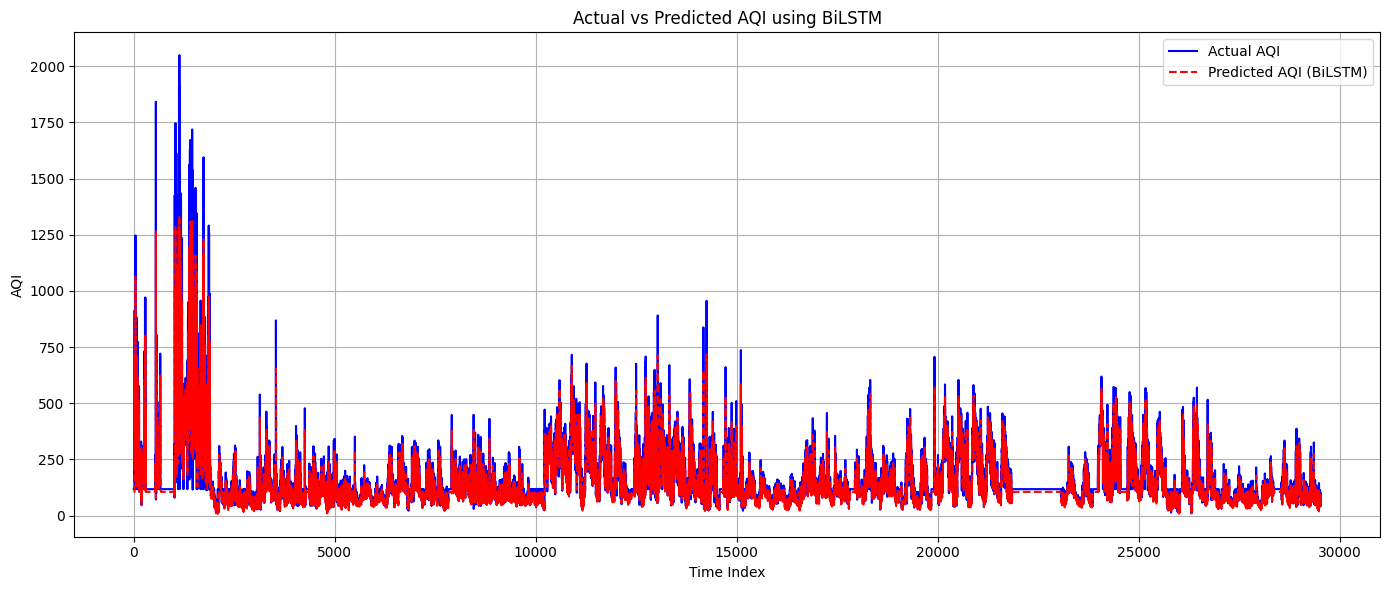

In [2]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# Load AQI dataset
df = pd.read_csv("./AirQuality_Cleaned.csv")  # Replace if needed
aqi_values = df['AQI'].values.reshape(-1, 1)

# Normalize AQI values
scaler = MinMaxScaler()
aqi_scaled = scaler.fit_transform(aqi_values)

# Sequence creation
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(aqi_scaled, seq_length)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Create DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Define BiLSTM model
class BiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_directions = 2 if bidirectional else 1
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout, 
                            batch_first=True, bidirectional=bidirectional)
        self.fc = nn.Linear(hidden_size * self.num_directions, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Use output of last timestep
        return out

model = BiLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train BiLSTM model
num_epochs = 70
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            output = model(batch_X)
            loss = criterion(output, batch_y)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Load best model and predict
model.load_state_dict(best_model)
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_tensor).numpy()

# Inverse scale predictions
predicted_aqi = scaler.inverse_transform(predictions_scaled)
actual_aqi = scaler.inverse_transform(y_tensor.numpy())

# Evaluation
mae = mean_absolute_error(actual_aqi, predicted_aqi)
mse = mean_squared_error(actual_aqi, predicted_aqi)
rmse = np.sqrt(mse)
r2 = r2_score(actual_aqi, predicted_aqi)
mape = np.mean(np.abs((actual_aqi - predicted_aqi) / actual_aqi)) * 100
accuracy = 100 - mape

print("\nFinal Model Evaluation:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(actual_aqi, label='Actual AQI', color='blue')
plt.plot(predicted_aqi, label='Predicted AQI (BiLSTM)', color='red', linestyle='--')
plt.title('Actual vs Predicted AQI using BiLSTM')
plt.xlabel('Time Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
